# Zarr cubes — incremental writes with `DatasetCollection`

A real-world raster archive is rarely a one-shot write: new timesteps land daily or
monthly, the occasional bad timestep needs replacing, and reads are large enough that
you don't want to materialise the whole cube at once.

`DatasetCollection.to_zarr` / `from_zarr` cover exactly that workflow:

1. Write an initial cube of N timesteps.
2. **Append** new timesteps as they arrive (`append_dim="time"`).
3. **Overwrite** a specific time slice in place (`region={"time": slice(a, b)}`).
4. Read the cube back as a **lazy** dask array and reduce over time without loading
   everything.

The cube is stored as a 4-D array `(time, band, row, col)` in the same GeoZarr layout
single rasters use — so the same store is openable by any standards-aware reader.

## Setup

Build a tiny synthetic 3-month rainfall stack — three single-band rasters on the same
grid, one per timestep, that we'll then write, extend, and reduce.

In [1]:
import os
os.environ["MPLBACKEND"] = "Agg"
%matplotlib inline

import tempfile
from pathlib import Path

import numpy as np

from pyramids.dataset import Dataset
from pyramids.dataset.collection import DatasetCollection

workspace = Path(tempfile.mkdtemp(prefix="pyramids-zarr-cube-"))
print("workspace:", workspace)

ROWS, COLS = 24, 24

def make_step(value: float, name: str) -> Path:
    """Write a 1-band tif filled with `value` on a shared lat/lon grid."""
    arr = np.full((1, ROWS, COLS), value, dtype=np.float32)
    d = Dataset.create_from_array(
        arr,
        top_left_corner=(0.0, float(ROWS)),
        cell_size=1.0,
        epsg=4326,
        no_data_value=-9999.0,
    )
    d.band_names = ["rainfall_mm"]
    path = workspace / f"{name}.tif"
    d.to_file(path)
    return path

jan = [make_step(10.0, "jan")]
feb = [make_step(20.0, "feb")]
mar = [make_step(30.0, "mar")]
print("step files:", [p.name for p in (jan + feb + mar)])

2026-05-28 23:23:26 | INFO | pyramids.base.config | Logging is configured.


workspace: C:\Users\main\AppData\Local\Temp\pyramids-zarr-cube-psiyqt9v
step files: ['jan.tif', 'feb.tif', 'mar.tif']


## 1. Initial cube write

Build a `DatasetCollection` from the January raster and write it as a fresh cube.

In [2]:
cube_store = workspace / "rainfall.zarr"

col_jan = DatasetCollection.from_files([str(p) for p in jan])
col_jan.to_zarr(cube_store)

col = DatasetCollection.from_zarr(cube_store)
print("timesteps :", col.time_length)
print("data shape:", col.data.shape, type(col.data).__name__)
print("epsg      :", col.base.epsg)

timesteps : 1
data shape: (1, 1, 24, 24) Array
epsg      : 4326


## 2. Append new timesteps over time

When the February raster lands, append it to the existing cube along the `time`
dimension. The store is resized in place; existing chunks are untouched.

In [3]:
DatasetCollection.from_files([str(p) for p in feb]).to_zarr(
    cube_store, mode="a", append_dim="time",
)
DatasetCollection.from_files([str(p) for p in mar]).to_zarr(
    cube_store, mode="a", append_dim="time",
)

col = DatasetCollection.from_zarr(cube_store)
print("timesteps :", col.time_length)
print("data shape:", col.data.shape)

# spot-check the per-timestep mean (each step was filled with one constant)
per_step_mean = col.data.mean(axis=(1, 2, 3)).compute()
print("per-step mean:", per_step_mean.tolist())

timesteps : 3
data shape: (3, 1, 24, 24)
per-step mean: [10.0, 20.0, 30.0]


## 3. Overwrite a region

Suppose March's raster was bad and we got a corrected version. Pass
`region={"time": slice(2, 3)}` to overwrite that exact slice — no resize, no rewrite of
the other timesteps.

In [4]:
fixed_mar = [make_step(35.0, "mar_fixed")]

DatasetCollection.from_files([str(p) for p in fixed_mar]).to_zarr(
    cube_store, mode="a", region={"time": slice(2, 3)},
)

col = DatasetCollection.from_zarr(cube_store)
per_step_mean = col.data.mean(axis=(1, 2, 3)).compute()
print("per-step mean after fix:", per_step_mean.tolist())
assert col.time_length == 3, "region writes must NOT resize the cube"

per-step mean after fix: [10.0, 20.0, 35.0]


## 4. Lazy reductions over time

`col.data` is a `dask.array` backed by the zarr store. Reductions only touch the chunks
they need:

In [5]:
time_mean = col.data.mean(axis=0).compute()   # (band, row, col)
time_max  = col.data.max(axis=0).compute()

print("time-mean shape:", time_mean.shape, "value:", float(time_mean.mean()))
print("time-max  shape:", time_max.shape,  "value:", float(time_max.max()))

time-mean shape: (1, 24, 24) value: 21.666667938232422
time-max  shape: (1, 24, 24) value: 35.0


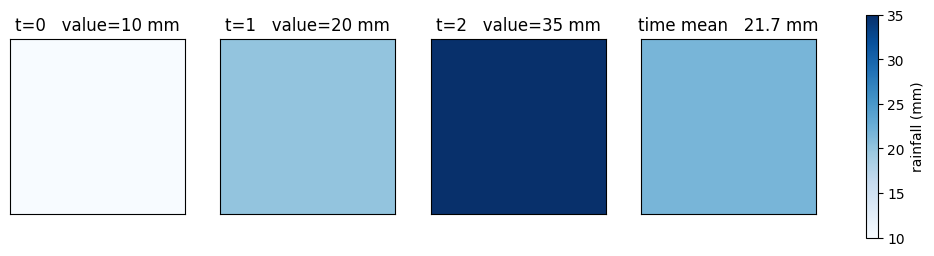

In [6]:
# --- Visualise the cube ---
# Each timestep was a single constant — Jan=10 mm, Feb=20 mm, Mar (after the region fix)
# = 35 mm — so the three left panels are flat-coloured at three increasing levels and the
# right-most panel shows the per-pixel time mean ((10+20+35)/3 ≈ 21.67). Sharing a single
# vmin/vmax across panels keeps the colour scale comparable. This is what makes "lazy
# reduction" tangible: the time-mean panel was built from a dask reduction that only
# touched what it needed, not the whole cube materialised in memory.
import matplotlib.pyplot as plt

cube = col.data.compute()
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
vmin, vmax = float(cube.min()), float(cube.max())
for t, ax in enumerate(axes[:3]):
    im = ax.imshow(cube[t, 0], cmap="Blues", vmin=vmin, vmax=vmax)
    ax.set_title(f"t={t}   value={float(cube[t].mean()):.0f} mm")
    ax.set_xticks([]); ax.set_yticks([])
im_mean = axes[3].imshow(time_mean[0], cmap="Blues", vmin=vmin, vmax=vmax)
axes[3].set_title(f"time mean   {float(time_mean.mean()):.1f} mm")
axes[3].set_xticks([]); axes[3].set_yticks([])
fig.colorbar(im_mean, ax=axes, shrink=0.85, label="rainfall (mm)")


## 5. Guardrails

- `mode="a"` without `append_dim` or `region` raises — there is no silent "open without
  overwriting" mode.
- Region writes do **not** resize the cube; they must land in an existing slice.
- Appending uses `append_dim="time"` exclusively; the cube's other dimensions are
  fixed by the initial write.

## Where to go next

- The single-raster basics: [`zarr-basics.ipynb`](zarr-basics.ipynb) — compressor choices
  and multiscale pyramid writes.
- Full API surface and the on-disk GeoZarr layout: [Zarr reference](../../reference/zarr.md).
- Cloud stores: `to_zarr` / `from_zarr` accept any URL zarr v3 understands
  (`s3://`, `gs://`, `az://`, …); pass credentials via `storage_options={...}`.
